In [6]:
import torch.nn as nn
from transformers import CLIPModel
import matplotlib.pyplot as plt
import pickle
from torch.utils.data import Dataset
import numpy as np
import json
import torch
import os
from tqdm.notebook import tqdm
import torch.nn.functional as F

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [7]:
image_set = "h&m"
text_set = "nemotron"
mode = "val"
embedding_mode = "clip"

In [8]:
if mode == "test":
    with open(f'../data_preparation/{text_set}/{embedding_mode}/test_persona_embeddings.pkl', 'rb') as f:
        test_embeddings = pickle.load(f)
    with open(f'../generate_test_set/{image_set + "+" + text_set}/test_indices.json', "r") as f:
        test_indices = json.load(f)
    with open(f'../data_preparation/{image_set}/pixel_values_test.pkl', 'rb') as f:
        test_pixel_values = torch.load(f, weights_only=False)
    with open(f'../data_preparation/{text_set}/test_personas.json', 'r') as f:
        personas = json.load(f)
    with open(f'../data_preparation/{image_set}/images_test.pkl', 'rb') as f:
        images = pickle.load(f)
elif mode == "val":
    with open(f'../data_preparation/{text_set}/{embedding_mode}/validation_persona_embeddings.pkl', 'rb') as f:
        test_embeddings = pickle.load(f)
    with open(f'../generate_test_set/{image_set + "+" + text_set}/val_indices.json', "r") as f:
        test_indices = json.load(f)
    with open(f'../data_preparation/{image_set}/pixel_values_val.pkl', 'rb') as f:
        test_pixel_values = torch.load(f, weights_only=False)
    with open(f'../data_preparation/{text_set}/validation_personas.json', 'r') as f:
        personas = json.load(f)
    with open(f'../data_preparation/{image_set}/images_val.pkl', 'rb') as f:
        images = pickle.load(f)

In [9]:
class PersonaImageDataset(Dataset):
    def __init__(self, personas, images, image_indices, scores, transform=None):
        self.personas = personas
        self.images = images
        self.scores = scores
        self.image_indices = image_indices
        self.transform = transform

    def __len__(self):
        return len(self.image_indices)

    def __getitem__(self, idx):
        img = self.images[self.image_indices[idx]]
        persona = self.personas[idx]
        score = self.scores[idx]

        if self.transform:
            img = self.transform(img)

        return (persona, img) , score

In [10]:
device = "cuda:1"

In [11]:
if embedding_mode == "openai":

    class FashionCLIPImageEncoder(nn.Module):
        def __init__(self):
            super().__init__()
            self.vision_encoder = CLIPModel.from_pretrained(
                "patrickjohncyh/fashion-clip"
            ).vision_model

            self.projection = nn.Linear(768, 1536)

        def forward(self, pixel_values):
            x = self.vision_encoder(pixel_values).pooler_output
            x = self.projection(x)
            return x

elif embedding_mode == "clip":

    class FashionCLIPImageEncoder(nn.Module):
        def __init__(self):
            super().__init__()
            # Load the full model temporarily to extract projection weights
            full_clip_model = CLIPModel.from_pretrained(
                "patrickjohncyh/fashion-clip"
            )

            # Extract vision encoder
            self.vision_encoder = full_clip_model.vision_model

            # Extract the visual projection layer weights
            self.projection = nn.Linear(768, 512, bias=False)
            self.projection.weight.data = (
                full_clip_model.visual_projection.weight.data.clone()
            )

            # Delete the full model to save memory
            del full_clip_model

        def forward(self, pixel_values):
            x = self.vision_encoder(pixel_values).pooler_output
            x = self.projection(x)
            return x

model = FashionCLIPImageEncoder().to(device)

In [12]:
import torch

def run_model_in_batches(model, pixel_values, batch_size=32, device='cuda'):
    model.eval()
    results = []

    with torch.no_grad():
        for i in range(0, len(pixel_values), batch_size):
            batch = pixel_values[i:i + batch_size].to(device)
            output = model(batch)
            results.append(output)

    # Concatenate outputs if they are tensors
    if isinstance(results[0], torch.Tensor):
        results = torch.cat(results, dim=0)
    
    return results

In [13]:
medians = []
means = []
sorted_indices_list = []

In [14]:
len(test_indices)

50

In [15]:
# state_dict = torch.load(f'{image_set + "+" + text_set}/{embedding_mode}/drift_weights/model_weights{-1}.pth', map_location=torch.device("cuda"))
# model.load_state_dict(state_dict)
# model.eval()
# output = model(test_pixel_values[0:6].to("cuda:1"))
# print(output)
# step_n = 0
# model.eval()
# print(step_n -1)
# state_dict = torch.load(f'{image_set + "+" + text_set}/{embedding_mode}/drift_weights/model_weights{-1}.pth', map_location=torch.device("cuda"))
# model.load_state_dict(state_dict, strict=False)
# test_results = run_model_in_batches(model, test_pixel_values, batch_size=8, device=device).float()
# print(test_results)

#When batch size goes from 5 -> 6 the first float increases by 0.001 inexplicably.

  0%|          | 0/50 [00:00<?, ?it/s]

top 5:  0.02 top 20:  0.14 top 100:  0.32 top 500:  0.6200000000000002
Mean rank:  0.8426513671875 Median rank:  0.925048828125 Top quartile:  0.98223876953125


C:\Users\ericy\AppData\Local\Temp\ipykernel_28908\3019308734.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_indices = torch.tensor(test_indices)


  0%|          | 0/50 [00:00<?, ?it/s]

top 5:  0.04 top 20:  0.14 top 100:  0.34 top 500:  0.6000000000000002
Mean rank:  0.8439013671875 Median rank:  0.9251708984375 Top quartile:  0.982421875


...

top 5:  0.06 top 20:  0.14 top 100:  0.4000000000000001 top 500:  0.7600000000000003
Mean rank:  0.8866943359375 Median rank:  0.9560546875 Top quartile:  0.9915771484375


  0%|          | 0/50 [00:00<?, ?it/s]

top 5:  0.06 top 20:  0.14 top 100:  0.38000000000000006 top 500:  0.7600000000000003
Mean rank:  0.8870166015625 Median rank:  0.9569091796875 Top quartile:  0.99139404296875


  0%|          | 0/50 [00:00<?, ?it/s]

top 5:  0.06 top 20:  0.14 top 100:  0.4000000000000001 top 500:  0.7600000000000003
Mean rank:  0.8870556640625 Median rank:  0.9580078125 Top quartile:  0.9915771484375


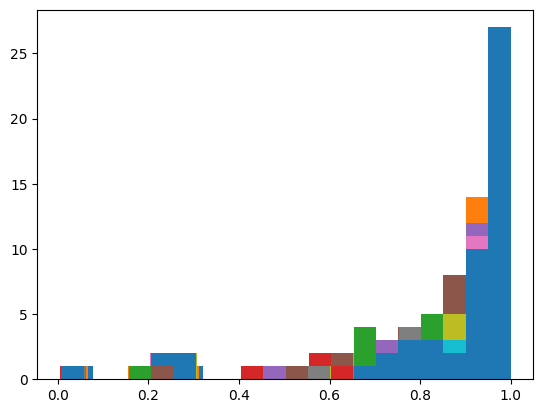

In [16]:
if os.path.exists(f'{image_set + "+" + text_set}/{embedding_mode}/results/{mode}/sorted_indices_list.pkl') == False:
    datasets = []
    for step_n in range(len(os.listdir(f'{image_set + "+" + text_set}/{embedding_mode}/drift_weights'))):
        model.eval()
        state_dict = torch.load(f'{image_set + "+" + text_set}/{embedding_mode}/drift_weights/model_weights{step_n-1}.pth', map_location=torch.device("cuda"))
        model.load_state_dict(state_dict, strict=False)
        test_results = run_model_in_batches(model, test_pixel_values, batch_size=32, device=device).float()
        test_embeddings = test_embeddings.to(device).float()
        test_results_norm = F.normalize(test_results, p=2, dim=1)
        test_embeddings_norm = F.normalize(test_embeddings, p=2, dim=1)
        test_cosine_sim = torch.matmul(test_results_norm, test_embeddings_norm.T)
        test_sorted_values, test_sorted_indices = torch.sort(test_cosine_sim, dim=0)
        test_indices = torch.tensor(test_indices)
        test_score = 0
        top_5 = 0
        top_20 = 0
        top_100 = 0
        top_500 = 0
        L = []

        sorted_indices_list.append(test_sorted_indices.cpu().numpy())

        for i in tqdm(range(len(test_indices))):
            test_sorted_indices_column = test_sorted_indices[:, i]
            n = test_sorted_indices_column.tolist().index(test_indices[i])
            L.append((n / len(test_sorted_indices_column)))
            if (len(test_sorted_indices_column)- n) < 5:
                top_5 += 1/len(test_indices)
            if (len(test_sorted_indices_column)- n) < 20:
                top_20 += 1/len(test_indices)
            if (len(test_sorted_indices_column)- n) < 100:
                top_100 += 1/len(test_indices)
            if (len(test_sorted_indices_column)- n) < 500:
                top_500 += 1/len(test_indices)

        print("top 5: ", top_5, "top 20: ", top_20, "top 100: ", top_100, "top 500: ", top_500)
        print("Mean rank: ", np.mean(L), "Median rank: ", np.median(L), "Top quartile: ", np.percentile(L, 75))
        _ = plt.hist(L, bins=20)

        medians.append(np.median(L))
        means.append(np.mean(L))

        datasets.append(L)

In [17]:
if os.path.exists(f'{image_set + "+" + text_set}/{embedding_mode}/results/{mode}/sorted_indices_list.pkl') == False:
    with open(f'{image_set + "+" + text_set}/{embedding_mode}/results/{mode}/medians.pkl', 'wb') as f:
        pickle.dump(medians, f)
    with open(f'{image_set + "+" + text_set}/{embedding_mode}/results/{mode}/means.pkl', 'wb') as f:
        pickle.dump(means, f)
    with open(f'{image_set + "+" + text_set}/{embedding_mode}/results/{mode}/datasets.pkl', 'wb') as f:
        pickle.dump(datasets, f)
    with open(f'{image_set + "+" + text_set}/{embedding_mode}/results/{mode}/sorted_indices_list.pkl', 'wb') as f:
        pickle.dump(sorted_indices_list, f)
else:
    with open(f'{image_set + "+" + text_set}/{embedding_mode}/results/{mode}/medians.pkl', 'rb') as f:
        medians = pickle.load(f)
    with open(f'{image_set + "+" + text_set}/{embedding_mode}/results/{mode}/means.pkl', 'rb') as f:
        means = pickle.load(f)
    with open(f'{image_set + "+" + text_set}/{embedding_mode}/results/{mode}/datasets.pkl', 'rb') as f:
        datasets = pickle.load(f)
    with open(f'{image_set + "+" + text_set}/{embedding_mode}/results/{mode}/sorted_indices_list.pkl', 'rb') as f:
        sorted_indices_list = pickle.load(f)

Giorgio, a man of routines, finds comfort in the familiar, whether it's his morning chess game or his evening choir practice, always balancing his ambitious career goals with his deeply rooted community values.


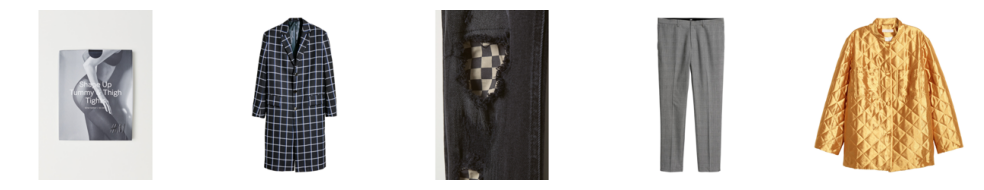

In [18]:
n = 1
print(personas[n])

stop_step = 0

img_list = [images[k] for k in sorted_indices_list[stop_step][:, n][::-1]]

num_images = 5
cols = 10  # images per row
rows = int(np.ceil(num_images / cols))

plt.figure(figsize=(cols * 2, rows * 2))  # adjust size as needed

for i in range(num_images):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img_list[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML

fig, ax = plt.subplots()
bins = np.linspace(0, 1, 21)
hist = ax.hist([], bins=bins)[2]  # Initialize empty bar container

def init():
    for bar in hist:
        bar.set_height(0)
    return hist

def update(frame):
    ax.clear()  # Optional: clear axis for different scales
    ax.hist(datasets[frame], bins=bins, color='skyblue', edgecolor='black')
    ax.axvline(x=means[frame], color='red', linestyle='--', linewidth=2, label='Mean')
    ax.axvline(x=medians[frame], color='green', linestyle='--', linewidth=2, label='Median')
    ax.set_ylim(0, 40)
    ax.set_title(f'Histogram of top image placements - Training step {frame}')
    return ax.patches

anim = FuncAnimation(fig, update, frames=len(datasets), init_func=init, blit=False, repeat=False)
anim.save(f'../images/histogram_{image_set}_{text_set}_{mode}.gif', writer=PillowWriter(fps=10))

plt.close()  # Prevent static plot from showing
HTML(anim.to_jshtml())  # Show animation in notebook


In [20]:
import json
with open(f'../other_approaches/scores.json', 'r') as f:
    scores = json.load(f)

median_score = scores[image_set + "+" + text_set][0]
mean_score = scores[image_set + "+" + text_set][1]

In [21]:
data = [{"step_n": i, "median": medians[i], "mean": means[i]} for i in range(len(medians))]

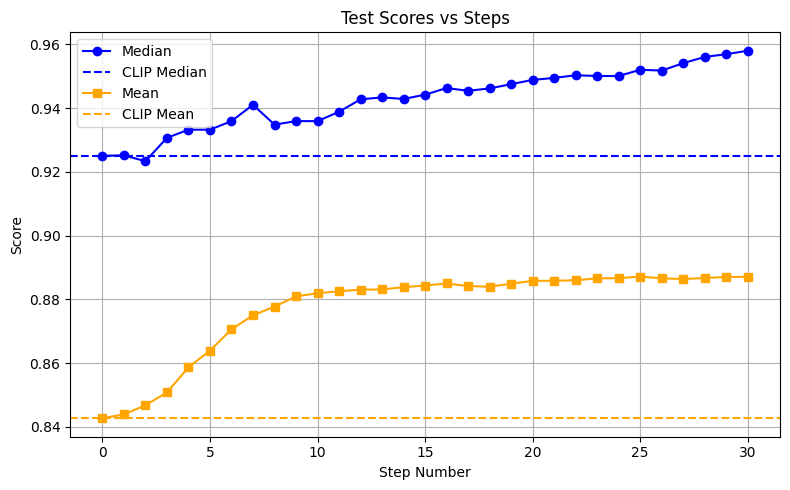

In [22]:
import json
import matplotlib.pyplot as plt

plot_median = True

# Extract data
steps = [item['step_n'] for item in data]
medians = [item['median'] for item in data]
means = [item['mean'] for item in data]

# Plotting
plt.figure(figsize=(8, 5))
if plot_median:
    plt.plot(steps, medians, marker='o', label='Median', color = 'blue')
    plt.axhline(y=medians[0], color='blue', linestyle='--', label='CLIP Median')
plt.plot(steps, means, marker='s', label='Mean', color = 'orange')
plt.axhline(y=means[0], color='orange', linestyle='--', label='CLIP Mean')

plt.title('Test Scores vs Steps')
plt.xlabel('Step Number')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()


In [23]:
if mode == "val":
    max_mean = 0
    counter = 0
    for i, mean in enumerate(means):
        if mean > max_mean:
            max_mean = mean
            counter = 0
        else:
            counter += 1
        print(i, "Mean:", mean, "Max Mean:", max_mean, "Counter:", counter)
        if counter >= 5:
            break
    print(i)

0 Mean: 0.8426513671875 Max Mean: 0.8426513671875 Counter: 0
1 Mean: 0.8439013671875 Max Mean: 0.8439013671875 Counter: 0
2 Mean: 0.846748046875 Max Mean: 0.846748046875 Counter: 0
3 Mean: 0.85080078125 Max Mean: 0.85080078125 Counter: 0
4 Mean: 0.858642578125 Max Mean: 0.858642578125 Counter: 0
5 Mean: 0.86390625 Max Mean: 0.86390625 Counter: 0
6 Mean: 0.87056640625 Max Mean: 0.87056640625 Counter: 0
7 Mean: 0.87498046875 Max Mean: 0.87498046875 Counter: 0
8 Mean: 0.877705078125 Max Mean: 0.877705078125 Counter: 0
9 Mean: 0.880927734375 Max Mean: 0.880927734375 Counter: 0
10 Mean: 0.8818994140625 Max Mean: 0.8818994140625 Counter: 0
11 Mean: 0.8825439453125 Max Mean: 0.8825439453125 Counter: 0
12 Mean: 0.883017578125 Max Mean: 0.883017578125 Counter: 0
13 Mean: 0.88310546875 Max Mean: 0.88310546875 Counter: 0
14 Mean: 0.88380859375 Max Mean: 0.88380859375 Counter: 0
15 Mean: 0.88431640625 Max Mean: 0.88431640625 Counter: 0
16 Mean: 0.8849853515625 Max Mean: 0.8849853515625 Counter: 0


In [24]:
early_stopping_path = "early_stopping.json"
key = image_set + "+" + text_set

if mode == "val":
    print(f"Setting early stopping epoch for {key} to {i}")
    if os.path.exists(early_stopping_path):
        with open(early_stopping_path, "r") as f:
            early_stopping_data = json.load(f)
    else:
        early_stopping_data = {}

    early_stopping_data[key] = i

    with open(early_stopping_path, "w") as f:
        json.dump(early_stopping_data, f, indent=2)
else:
    with open(early_stopping_path, "r") as f:
        early_stopping_data = json.load(f)
    if key in early_stopping_data:
        early_stopping_epoch = early_stopping_data[key]
        print(f"Early stopping epoch for {key}: {early_stopping_epoch}")
        print(f"Mean at early stopping: {means[early_stopping_epoch]}")
    else:
        print(f"No early stopping epoch found for {key}")

Setting early stopping epoch for h&m+nemotron to 30
